In [2]:
import helpers
import importlib
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1,EFSM,1,UDS,1000,16,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2,EFSM,1,UDS,1000,32,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3,EFSM,1,UDS,1000,64,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4,EFSM,1,UDS,1000,128,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5,EFSM,1,UDS,1000,256,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [23]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager
# efsm_group=CaseManager([40,41,42,43,45,46, 47], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000)
efsm_group=CaseManager([80, 81, 82, 83, 84, 85, 86, 87,88,89,90,91,92,93], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000)

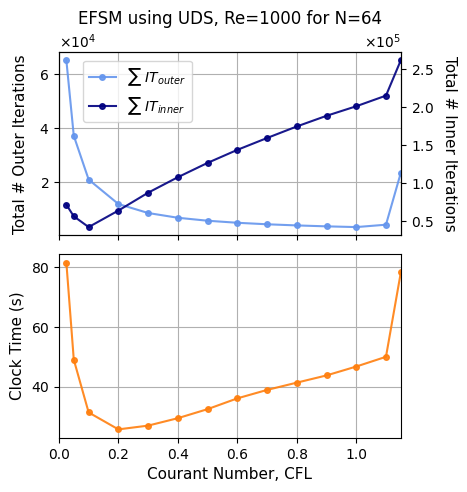

In [67]:


fig, axes = plt.subplots(2, 1, figsize=(4.75, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}

ax0_copy = axes[0].twinx()
for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    
    ax.set_xlim(0,1.15)

# --- get first group only ---
group=efsm_group

meta_df =  group.compare_meta()
DX = 1 / meta_df['N']
meta_df['CFL'] = meta_df['DT'] / DX
meta_df = meta_df.sort_values(by='CFL')

label_outer = r"$\sum~ IT_{outer}$"
label_inner = r"$\sum~ IT_{inner}$"

# Plot on main axis
l1, = axes[0].plot(meta_df['CFL'], meta_df["IT"], 'o-', markersize=4,label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue", zorder=2)
# Plot on twin axis
l2, = ax0_copy.plot(meta_df['CFL'], meta_df["total_inner_iterations"], 'o-', markersize=4,label=label_inner, alpha=0.9, linewidth=1.5, zorder=1, color="navy")
# Plot on second subplot
l3, = axes[1].plot(meta_df['CFL'], meta_df["clock_time"], 'o-', label="Clock Time", markersize=4,alpha=0.9, linewidth=1.5, color="C1")

# Formatting
axes[0].set_ylabel("Total # Outer Iterations", fontsize=11, labelpad=8)
ax0_copy.set_ylabel("Total # Inner Iterations", rotation=270, labelpad=17,fontsize=11)
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax0_copy.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel("Clock Time (s)",fontsize=11)
axes[1].set_xlabel("Courant Number, CFL",fontsize=11)
axes[0].grid()
axes[1].grid()
# --- Single combined legend ---
leg = axes[0].legend(handles=[l1, l2], loc='upper left', bbox_to_anchor=(0.05, 0.99), framealpha=0.8, fontsize=10)
leg.set_zorder(10)

fig.subplots_adjust(wspace=0.35)
axes[0].set_title("EFSM using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)

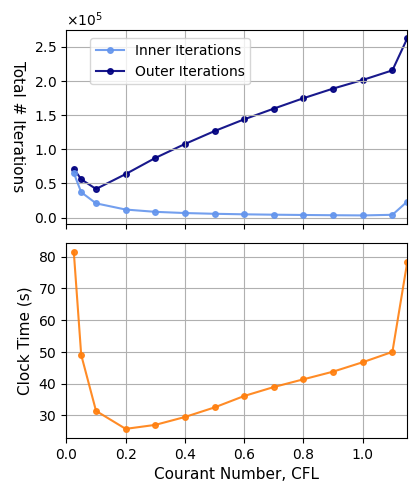

In [70]:


fig, axes = plt.subplots(2, 1, figsize=(4.25, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}

# ax0_copy = axes[0].twinx()
for ax in [axes[0], axes[1]]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    
    ax.set_xlim(0,1.15)

# --- get first group only ---
group=efsm_group

meta_df =  group.compare_meta()
DX = 1 / meta_df['N']
meta_df['CFL'] = meta_df['DT'] / DX
meta_df = meta_df.sort_values(by='CFL')

label_outer = r"Inner Iterations"
label_inner = r"Outer Iterations"

# Plot on main axis
l1, = axes[0].plot(meta_df['CFL'], meta_df["IT"], 'o-', markersize=4,label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue", zorder=2)
# Plot on twin axis
l2, = axes[0].plot(meta_df['CFL'], meta_df["total_inner_iterations"], 'o-', markersize=4,label=label_inner, alpha=0.9, linewidth=1.5, zorder=1, color="navy")
# Plot on second subplot
l3, = axes[1].plot(meta_df['CFL'], meta_df["clock_time"], 'o-', label="Clock Time", markersize=4,alpha=0.9, linewidth=1.5, color="C1")

# Formatting
# axes[0].set_ylabel("Total # Outer Iterations", fontsize=11, labelpad=8)
axes[0].set_ylabel("Total # Iterations", rotation=270, labelpad=17,fontsize=11)
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel("Clock Time (s)",fontsize=11)
axes[1].set_xlabel("Courant Number, CFL",fontsize=11)
axes[0].grid()
axes[1].grid()
# --- Single combined legend ---
leg = axes[0].legend(handles=[l1, l2], loc='upper left', bbox_to_anchor=(0.05, 0.99), framealpha=0.8, fontsize=10)
leg.set_zorder(10)

fig.subplots_adjust(wspace=0.35)
# axes[0].set_title("EFSM using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)

In [54]:
simple_group=CaseManager([59,60,61,62,63, 64,65,66], solution_method="SIMPLE", N=64, conv_scheme="uds", RE=1000)

Convergence dataframe is empty!


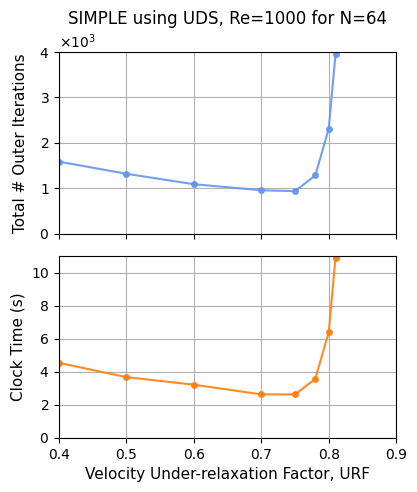

In [66]:
case_df = pd.read_excel("cases.xlsx")
case_df.head()

fig, axes = plt.subplots(2, 1, figsize=(4.25, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}


for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.set_xlim(0.4,0.9)

# --- get first group only ---
group=simple_group
meta_df =  group.compare_meta()
DX = 1 / meta_df['N']

label_outer = f"# Outer Iterations"
label_inner = "# Inner Iterations"

# Plot on main axis
case_df_slice = case_df[case_df["case"].isin(list(simple_group.cases.keys()))].copy().sort_values(by="URFU")
IT=case_df[case_df["case"].isin(list(simple_group.cases.keys()))]['IT']

l1, = axes[0].plot(case_df_slice['URFU'], case_df_slice["IT"], 'o-', markersize=4,label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue", zorder=2)
# Plot on twin axis

# Plot on second subplot
l3, = axes[1].plot(case_df_slice['URFU'], case_df_slice["clock_time"], 'o-', markersize=4,label="Clock Time", alpha=0.9, linewidth=1.5, color="C1")

# Formatting
axes[0].set_ylabel("Total # Outer Iterations",fontsize=11, labelpad=8)
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axes[1].set_ylabel("Clock Time (s)",fontsize=11)
axes[1].set_xlabel("Velocity Under-relaxation Factor, URF",fontsize=11)
axes[0].grid()
axes[1].grid()

axes[0].set_ylim(0,4000)
axes[1].set_ylim(0,11)
fig.subplots_adjust(wspace=0.35)
axes[0].set_title("SIMPLE using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)